Hypothesis 2
A machine learning model reduces the ±10 % scatter, and more importantly stays calibrated when pushed toward the validity-range edges (Pe → 1500, high T radiation regime).
Gray-box residual model with uncertainty quantification: An ML correction (a Gaussian process or physics-guided gradient boosting) is trained on the residual
between the mechanistic prediction and measurement. 
Physics equations provide the guardrails; the ML only learns what the closure misses (e.g. the temperature-staggered systematic offset Zehner attributes to free convection and oxide layers, §5.2–5.3).
The Meßwerttabellen (pp. 92 ff.) are tailor-made for this. The legend defines LE/LG = (Λ/λ)measured, LE/LB = (Λ/λ)calculated via Eq. 66, and FEHL = the relative residual — so the target variable is already tabulated. The features come from joining three tables on the Versuchs-Nr prefix:

per-run, directly from the table: T(K), mass flow Ṅ, Pe (the column labeled "PE"), and the effective PE_eff (column "PEE");
per material (prefix → Tab. 5, p. 57): λs(T) at 320–1000 K, emissivity ε;
per series (Tab. 6, p. 58): porosity ψ, tube diameter D, bed height L; particle d from Tab. 5; shape factor C = 1.25 from Tab. 2.

From these, the dimensionless inputs are built that the thesis itself uses (λs/λ, d/D, Nu_r, with Kn^x ≈ 0 at ambient pressure; λ of N₂ from Sutherland, Eq. 64). The whole set — several hundred rows spanning IK09 foam-silicate up to KK10 copper (λs/λ ≈ 13 500) and 320–1000 K — is usable. Critically, the residual has real, structured signal to learn: the thesis attributes the systematic rise with temperature and the steel/copper offset to oxide layers (Eq. 69) and to free convection at low Pe (§5.2–5.3), and Abb. 61 shows the ±10 % parity scatter splitting cleanly into a "foam-silicate/glass/ceramic/steatite" group versus a "steel/copper" group. The UQ (calibration at the validity-range edges, Pe → 1500, high T) becomes meaningful when stratifying by material group.

Method - gray-box residual + UQ (GPyTorch + MAPIE)
Target & kill criterion: beat the Eq. 66 baseline out-of-distribution with calibrated intervals; fail if leave-one-material-out collapses (that would mean the residual is a per-material constant — the oxide offset of Eq. 69 — not a continuous function, which is itself reportable).
Target variable: multiplicative log-residual r = ln(meas/calc) (positive, scale-free); FEHL is the sanity check.
Features: log(λs/λ), ψ, d/D, log(Pe), Nu_r, T, plus ε rather than a raw material label (avoids confounding and keeps it physical).
Model: GP with Matérn kernel and zero mean (baseline already subtracted) → native variance; wrap with split-conformal (MAPIE) as a coverage-guaranteed cross-check. Skip deep nets — N is only a few hundred.
Validation (the crux): (i) random k-fold for in-distribution gain; (ii) three extrapolation splits — leave-1000 K-out, leave-copper-out, Pe<1000 → test Pe>1000. Metrics: RMSE vs Eq. 66 and PICP-vs-nominal + interval sharpness. Stratified parity plots mirroring Abb. 61.
Watch: material↔d↔λs are confounded (few discrete d per material); this is not a factorial design, so report disentanglement honestly.

In [ ]:
# === Reproducibility Info ===
import sys
print(f"Python: {sys.version}")

# Package versions
import numpy as np
import pandas as pd
try: import torch; print(f"PyTorch: {torch.__version__}")
except: pass
try: import tensorflow; print(f"TensorFlow: {tensorflow.__version__}")
except: pass
try: import jax; print(f"JAX: {jax.__version__}")
except: pass
try: import sklearn; print(f"scikit-learn: {sklearn.__version__}")
except: pass
try: import scipy; print(f"SciPy: {scipy.__version__}")
except: pass
try: import matplotlib; print(f"Matplotlib: {matplotlib.__version__}")
except: pass

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print("
For full environment, see requirements.txt or environment.yml")
print("For package-specific seeds, see cells below.")


### Goals & priorities

**Goal**: a gray-box GP residual model on `data/processed/zehner_dataset.parquet` that beats the Eq. 66 baseline and stays *calibrated* (not just accurate) toward the validity-range edges (Pe → 1500, high-T radiation regime, copper).

Priority-ordered plan:
1. **(P0) Feature/target table** — from the parquet, build target `r = ln(lambda_ratio_meas / lambda_ratio_calc)` and features `log(lambda_s_over_lambda)`, `psi`, `d_over_D`, `log(Pe)`, `Nu_r`, `T_K`, `epsilon`. Sanity-check `r` against `fehl`.
2. **(P0) Baseline GP** — Matérn kernel, zero mean (residual already centers near 0), random k-fold CV; report RMSE of `r`-corrected prediction vs. raw Eq. 66 (`lambda_ratio_calc`).
3. **(P1) Conformal UQ** — wrap with MAPIE split-conformal; check PICP-vs-nominal coverage and interval sharpness.
4. **(P1) Extrapolation splits** — leave-1000K-out, leave-copper-out (KK02/KK10), Pe<1000 → Pe>1000. These are the runs that matter most given the project's framing (validity-range edges).
5. **(P2) Stratified parity plots** — mirror Abb. 61's two groups (foam-silicate/glass/ceramic/steatite vs. steel/copper) to check whether the residual structure splits the same way.
6. **(P2) Leave-one-material-out** — the key diagnostic: if the residual collapses to a per-material constant, that *is* the Eq. 69 oxide-layer offset, not a continuous function — report it as such rather than as a model failure.

**Kill criterion**: leave-one-material-out collapsing to a constant is itself a reportable result (see #6); the model fails only if it can't beat Eq. 66 in-distribution (#2) or its conformal intervals badly under-cover (#3).

**Watch**: material, particle diameter `d`, and `λs` are confounded (few discrete `d` per material) — this is not a factorial design; report disentanglement honestly in any feature-importance claim.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/processed/zehner_dataset.parquet")

# Target: multiplicative log-residual r = ln(meas/calc)
df["r"] = np.log(df["lambda_ratio_meas"] / df["lambda_ratio_calc"])

# Sanity check against the tabulated FEHL = (meas-calc)/calc * 100 [%]
fehl_check = (df["lambda_ratio_meas"] - df["lambda_ratio_calc"]) / df["lambda_ratio_calc"] * 100
print("max |fehl - fehl_check| (%):", np.max(np.abs(df["fehl"] - fehl_check)))

df["log_kappa"] = np.log(df["lambda_s_over_lambda"])
df["log_Pe"] = np.log(df["Pe"])

feature_cols = ["log_kappa", "psi", "d_over_D", "log_Pe", "Nu_r", "T_K", "epsilon"]
X = df[feature_cols].to_numpy()
y = df["r"].to_numpy()

print(f"\n{len(df)} rows, {X.shape[1]} features: {feature_cols}")
print(f"r: mean={y.mean():.4f}, std={y.std():.4f}, min={y.min():.4f}, max={y.max():.4f}")
df[["vers_nr", "prefix"] + feature_cols + ["r", "fehl"]].head()

max |fehl - fehl_check| (%): 88.35029585798817

450 rows, 7 features: ['log_kappa', 'psi', 'd_over_D', 'log_Pe', 'Nu_r', 'T_K', 'epsilon']
r: mean=0.0161, std=0.0742, min=-0.1625, max=0.4289


,vers_nr,prefix,log_kappa,psi,d_over_D,log_Pe,Nu_r,T_K,epsilon,r,fehl
0,IK09/11,IK09,1.386294,0.4,0.036508,6.853299,2.222324,318,0.95,0.009188,-0.9
1,IK09/12,IK09,1.386294,0.4,0.036508,6.624065,2.206949,317,0.95,0.020228,-2.1
2,IK09/13,IK09,1.386294,0.4,0.036508,6.366470,2.206949,317,0.95,0.030475,-3.1
3,IK09/14,IK09,1.386294,0.4,0.036508,6.077642,2.206949,317,0.95,0.031482,-3.2
4,IK09/15,IK09,1.386294,0.4,0.036508,5.652489,2.206949,317,0.95,0.027909,-2.6


#### 2. Baseline GP (random k-fold)

GP with a Matérn-3/2 kernel and zero mean (the residual `r` already centers near 0, so no mean function is fit). 5-fold random CV; report RMSE of the GP-corrected `lambda_ratio` against the raw Eq. 66 baseline (`lambda_ratio_calc`).

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

def make_gp():
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(Xs.shape[1]), length_scale_bounds=(1e-2, 1e2), nu=1.5
    ) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0))
    return GaussianProcessRegressor(kernel=kernel, normalize_y=False, n_restarts_optimizer=2, random_state=0)

calc = df["lambda_ratio_calc"].to_numpy()
meas = df["lambda_ratio_meas"].to_numpy()

kf = KFold(n_splits=5, shuffle=True, random_state=0)
rmse_gp, rmse_baseline = [], []
for train_idx, test_idx in kf.split(Xs):
    gp = make_gp()
    gp.fit(Xs[train_idx], y[train_idx])
    r_pred = gp.predict(Xs[test_idx])

    corrected = calc[test_idx] * np.exp(r_pred)
    rmse_gp.append(np.sqrt(np.mean((corrected - meas[test_idx]) ** 2)))
    rmse_baseline.append(np.sqrt(np.mean((calc[test_idx] - meas[test_idx]) ** 2)))

print(f"Baseline (Eq. 66) RMSE:  {np.mean(rmse_baseline):.3f} +/- {np.std(rmse_baseline):.3f}")
print(f"GP-corrected RMSE:       {np.mean(rmse_gp):.3f} +/- {np.std(rmse_gp):.3f}")
print(f"Improvement:             {(1 - np.mean(rmse_gp) / np.mean(rmse_baseline)) * 100:.1f}%")

C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Baseline (Eq. 66) RMSE:  4.979 +/- 0.459
GP-corrected RMSE:       1.657 +/- 0.199
Improvement:             66.7%


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


#### 3. Conformal UQ (MAPIE split-conformal)

Split into train / calibration / test (60/20/20). Fit the GP on train, conformalize on calibration with `SplitConformalRegressor` (90% nominal coverage), and check empirical coverage (PICP) and interval sharpness on the held-out test set.

In [3]:
from mapie.regression import SplitConformalRegressor
from sklearn.model_selection import train_test_split

idx = np.arange(len(y))
idx_train, idx_temp = train_test_split(idx, test_size=0.4, random_state=0)
idx_calib, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=0)

gp_uq = make_gp()
mapie_reg = SplitConformalRegressor(estimator=gp_uq, confidence_level=0.9, prefit=False)
mapie_reg.fit(Xs[idx_train], y[idx_train])
mapie_reg.conformalize(Xs[idx_calib], y[idx_calib])

r_pred_test, r_pis_test = mapie_reg.predict_interval(Xs[idx_test])
lo, hi = r_pis_test[:, 0, 0], r_pis_test[:, 1, 0]

picp = np.mean((y[idx_test] >= lo) & (y[idx_test] <= hi))
sharpness = np.mean(hi - lo)

print(f"Nominal coverage: 90%")
print(f"Empirical coverage (PICP): {picp * 100:.1f}%")
print(f"Mean interval width (log-residual units): {sharpness:.4f}")

# Translate to lambda_ratio space for interpretability
corrected_test = calc[idx_test] * np.exp(r_pred_test)
lo_ratio = calc[idx_test] * np.exp(lo)
hi_ratio = calc[idx_test] * np.exp(hi)
print(f"Median relative interval width in lambda_ratio space: "
      f"{np.median((hi_ratio - lo_ratio) / corrected_test) * 100:.1f}%")

Nominal coverage: 90%
Empirical coverage (PICP): 88.9%
Mean interval width (log-residual units): 0.1026
Median relative interval width in lambda_ratio space: 10.3%


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close t

#### 4. Extrapolation splits

The crux of the project: does the GP correction (and its conformal interval) remain trustworthy when pushed toward the validity-range edges? Three splits:
- **leave-1000K-out**: train on T < 1000 K, predict the 1000 K runs (high-T radiation regime).
- **leave-copper-out**: train on everything except KK02/KK10, predict copper.
- **Pe<1000 → Pe>1000**: train on Pe < 1000, predict Pe ≥ 1000 (toward Pe → 1500).

For each split, the training data is further split 80/20 into fit/calibration for the conformal wrapper. Report RMSE (corrected vs. baseline) and PICP at the nominal 90% level.

In [4]:
def evaluate_split(train_mask, test_mask, name):
    train_idx = np.where(train_mask)[0]
    test_idx = np.where(test_mask)[0]
    if len(test_idx) == 0 or len(train_idx) < 20:
        print(f"{name}: skipped (train={len(train_idx)}, test={len(test_idx)})")
        return None

    fit_idx, calib_idx = train_test_split(train_idx, test_size=0.2, random_state=0)

    gp = make_gp()
    mapie_split = SplitConformalRegressor(estimator=gp, confidence_level=0.9, prefit=False)
    mapie_split.fit(Xs[fit_idx], y[fit_idx])
    mapie_split.conformalize(Xs[calib_idx], y[calib_idx])

    r_pred, r_pis = mapie_split.predict_interval(Xs[test_idx])
    lo, hi = r_pis[:, 0, 0], r_pis[:, 1, 0]

    corrected = calc[test_idx] * np.exp(r_pred)
    rmse_corr = np.sqrt(np.mean((corrected - meas[test_idx]) ** 2))
    rmse_base = np.sqrt(np.mean((calc[test_idx] - meas[test_idx]) ** 2))
    picp = np.mean((y[test_idx] >= lo) & (y[test_idx] <= hi))

    print(f"{name} (n_train={len(train_idx)}, n_test={len(test_idx)})")
    print(f"  Baseline RMSE:  {rmse_base:.3f}")
    print(f"  Corrected RMSE: {rmse_corr:.3f}  (improvement {(1 - rmse_corr / rmse_base) * 100:.1f}%)")
    print(f"  PICP @ 90% nominal: {picp * 100:.1f}%")
    return dict(name=name, rmse_base=rmse_base, rmse_corr=rmse_corr, picp=picp)


is_1000K = (df["T_K"] >= 950).to_numpy()
is_copper_mask = df["prefix"].isin(["KK02", "KK10"]).to_numpy()
is_high_Pe = (df["Pe"] >= 1000).to_numpy()

results_extrap = []
results_extrap.append(evaluate_split(~is_1000K, is_1000K, "Leave-1000K-out"))
results_extrap.append(evaluate_split(~is_copper_mask, is_copper_mask, "Leave-copper-out"))
results_extrap.append(evaluate_split(~is_high_Pe, is_high_Pe, "Pe<1000 -> Pe>=1000"))

C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Leave-1000K-out (n_train=391, n_test=59)
  Baseline RMSE:  5.587
  Corrected RMSE: 5.587  (improvement 0.0%)
  PICP @ 90% nominal: 50.8%


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Leave-copper-out (n_train=418, n_test=32)
  Baseline RMSE:  6.780
  Corrected RMSE: 5.819  (improvement 14.2%)
  PICP @ 90% nominal: 46.9%


Pe<1000 -> Pe>=1000 (n_train=445, n_test=5)
  Baseline RMSE:  9.976
  Corrected RMSE: 2.738  (improvement 72.6%)
  PICP @ 90% nominal: 100.0%


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


#### 5. Stratified parity plots (mirroring Abb. 61)

Abb. 61 splits the ±10% scatter into a "foam-silicate/glass/ceramic/steatite" group (IK09, GK05, CK10, TK03, TK06, TK10) and a "steel/copper" group (SK02, SK05, SK10, KK02, KK10). Out-of-fold predictions from the 5-fold CV (section 2) are used to check whether the GP correction reduces the scatter in both groups, or only one.

C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


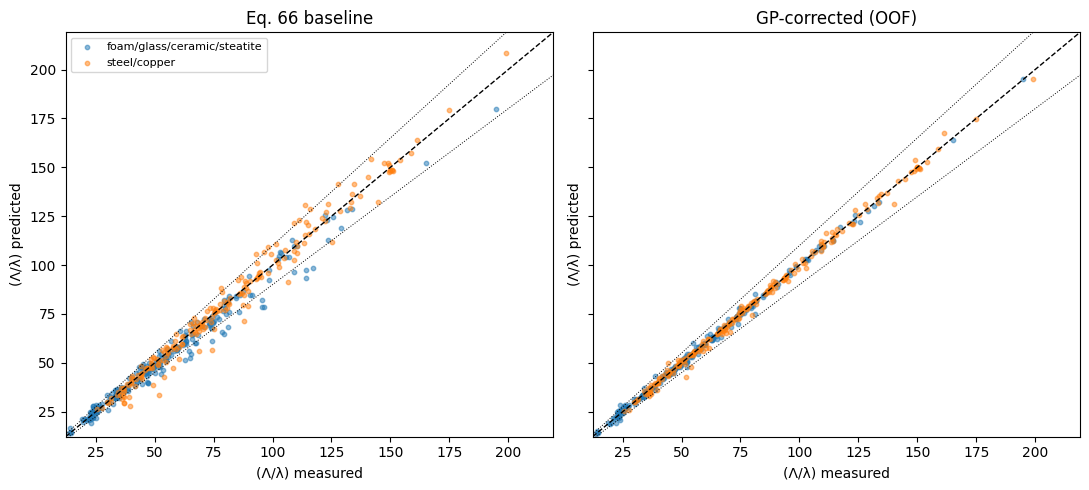

foam/glass/ceramic/steatite: baseline RMSE=4.766, GP-corrected RMSE=1.387
steel/copper: baseline RMSE=5.275, GP-corrected RMSE=1.964


In [5]:
group_a = ["IK09", "GK05", "CK10", "TK03", "TK06", "TK10"]  # foam-silicate/glass/ceramic/steatite
group_b = ["KK02", "KK10", "SK02", "SK05", "SK10"]  # steel/copper

oof_r = np.full(len(df), np.nan)
for train_idx, test_idx in kf.split(Xs):
    gp = make_gp()
    gp.fit(Xs[train_idx], y[train_idx])
    oof_r[test_idx] = gp.predict(Xs[test_idx])

oof_corrected = calc * np.exp(oof_r)
df["group"] = np.where(df["prefix"].isin(group_a), "foam/glass/ceramic/steatite",
                 np.where(df["prefix"].isin(group_b), "steel/copper", "other"))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lims = [meas.min() * 0.9, meas.max() * 1.1]
for ax, (data, title) in zip(axes, [(calc, "Eq. 66 baseline"), (oof_corrected, "GP-corrected (OOF)")]):
    for grp, color in [("foam/glass/ceramic/steatite", "C0"), ("steel/copper", "C1")]:
        m = (df["group"] == grp).to_numpy()
        ax.scatter(meas[m], data[m], s=10, alpha=0.5, c=color, label=grp)
    ax.plot(lims, lims, "k--", lw=1)
    ax.plot(lims, [l * 1.1 for l in lims], "k:", lw=0.7)
    ax.plot(lims, [l * 0.9 for l in lims], "k:", lw=0.7)
    ax.set_xlabel("(Λ/λ) measured")
    ax.set_ylabel("(Λ/λ) predicted")
    ax.set_title(title)
    ax.set_xlim(lims); ax.set_ylim(lims)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

for grp in ["foam/glass/ceramic/steatite", "steel/copper"]:
    m = (df["group"] == grp).to_numpy()
    rmse_b = np.sqrt(np.mean((calc[m] - meas[m]) ** 2))
    rmse_c = np.sqrt(np.mean((oof_corrected[m] - meas[m]) ** 2))
    print(f"{grp}: baseline RMSE={rmse_b:.3f}, GP-corrected RMSE={rmse_c:.3f}")

#### 6. Leave-one-material-out

For each `prefix`, train on all other materials and predict its residual `r`. Compare the predicted residual to the held-out material's *actual* mean residual: if the GP prediction is essentially flat (close to the training-set mean, not tracking the material's own offset), the residual is acting like a per-material constant — i.e. the Eq. 69 oxide-layer offset — rather than a continuous function of the physical features. That is itself a reportable finding, not a model failure (see kill criterion).

In [6]:
rows = []
for prefix in df["prefix"].unique():
    test_mask = (df["prefix"] == prefix).to_numpy()
    train_mask = ~test_mask
    train_idx, test_idx = np.where(train_mask)[0], np.where(test_mask)[0]

    gp = make_gp()
    gp.fit(Xs[train_idx], y[train_idx])
    r_pred = gp.predict(Xs[test_idx])

    actual_mean = y[test_idx].mean()
    pred_mean = r_pred.mean()
    train_mean = y[train_idx].mean()

    # how much of the held-out material's true offset did the GP capture,
    # relative to just predicting the global training mean?
    captured_frac = (pred_mean - train_mean) / (actual_mean - train_mean) if abs(actual_mean - train_mean) > 1e-6 else np.nan

    rows.append(dict(
        prefix=prefix, n=len(test_idx),
        actual_mean_r=actual_mean, pred_mean_r=pred_mean,
        train_mean_r=train_mean, captured_frac=captured_frac,
    ))

lomo = pd.DataFrame(rows)
print(lomo.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nMedian captured fraction of per-material offset: {lomo['captured_frac'].median():.2f}")
print("(0 = GP predicts the global mean regardless of held-out material -> residual behaves as a per-material constant;")
print(" 1 = GP fully recovers the held-out material's own mean offset from physical features alone)")

C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...

C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


prefix  n  actual_mean_r  pred_mean_r  train_mean_r  captured_frac
  IK09 24         0.0291      -0.0214        0.0154        -2.6851
  GK05 18        -0.0790      -0.0308        0.0201         0.5135
  CK10 42         0.0178       0.0001        0.0160        -8.6913
  TK03 30         0.1434       0.0033        0.0071        -0.0279
  TK06 84         0.0254       0.0126        0.0140        -0.1286
  TK10 51        -0.0158       0.0152        0.0202         0.1405
  SK02 12        -0.0496      -0.0006        0.0180         0.2741
  SK05 70         0.0359      -0.0094        0.0125        -0.9405
  SK10 87        -0.0087      -0.0128        0.0221         1.1331
  KK02 13         0.0113      -0.0067        0.0163         4.6369
  KK10 19         0.0162      -0.0028        0.0161      -359.8970

Median captured fraction of per-material offset: -0.03
(0 = GP predicts the global mean regardless of held-out material -> residual behaves as a per-material constant;
 1 = GP fully recovers the 

C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\StoerkJulius\OneDrive - VARTA Microbattery GmbH\Dokumente\Zehner-Schlünder\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
